[*********************100%***********************]  1 of 1 completed


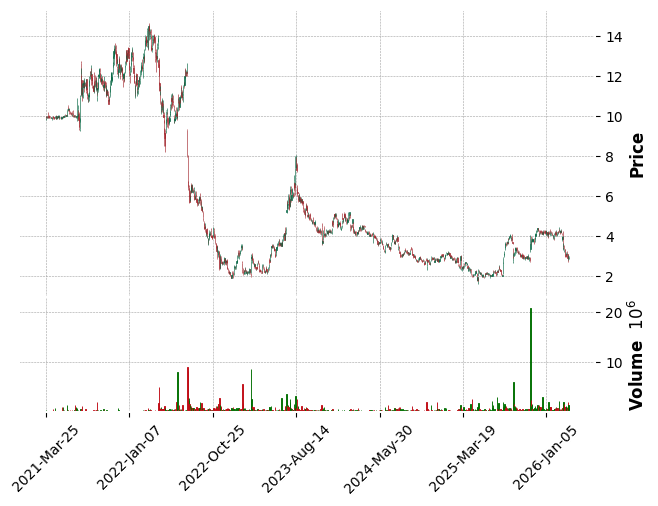

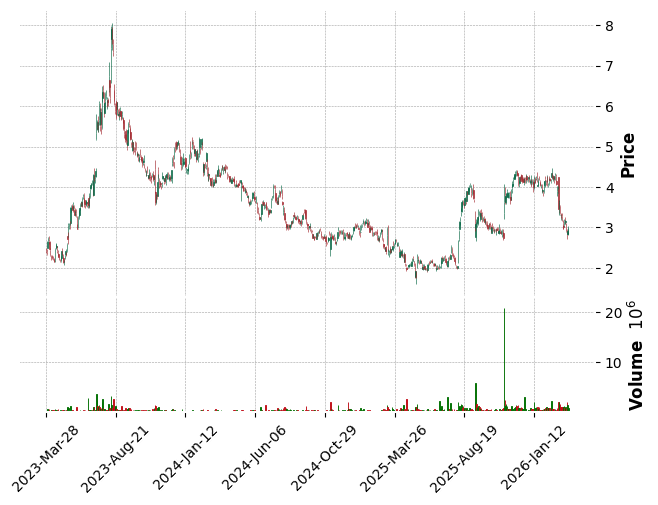

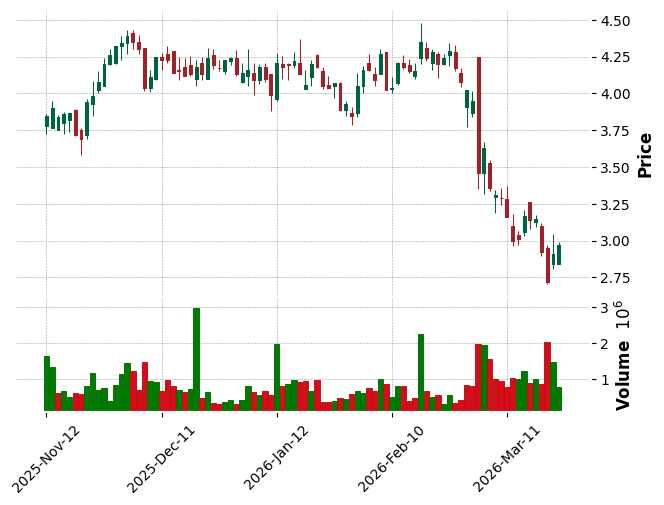

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


20.463636363636365


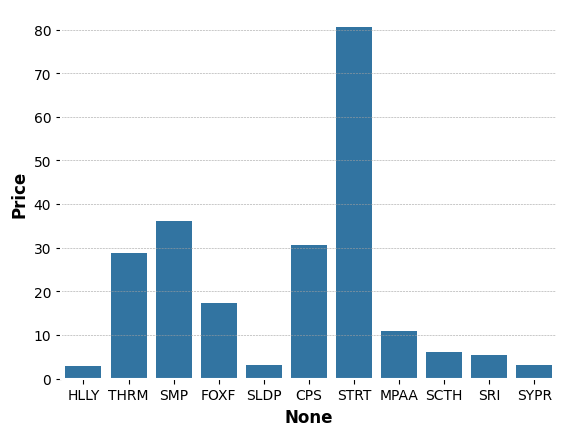

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [5]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [ ]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [ ]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

No Recent Activity


In [ ]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-13 17:30:58
Afya Limited 2025 Q4 - Results - Earnings Call Presentation
2026-03-13. The following slide deck was published by Afya Limited in conjunction with their 2025 Q4 earnings call.
https://finnhub.io/api/news?id=87f7e6aeb87e1daef88f39623746653b6e0e49de49b3c1a54d57acb209b7e26b

2026-03-13 00:52:25
Afya Limited (AFYA) Q4 2025 Earnings Call Transcript
Afya Limited (AFYA) Q4 2025 Earnings Call March 12, 2026 5:00 PM EDTCompany ParticipantsRenata Couto - Investor Relations Executive ManagerVirgilio Deloy...
https://finnhub.io/api/news?id=5762955defc1ac60af64316bbb0e5b44e34ab865b8b8a4e642b2651f87f28d74

2026-03-12 22:05:15
Reported earlier, Afya Sees FY2026 Sales $731.710M-$759.496M vs $763.950M Est
Afya (NASDAQ:AFYA) sees FY2026 sales of $731.710 million-$759.496 million vs $763.950 million analyst estimate.
https://finnhub.io/api/news?id=92edfbf9d90269c0085e98c58a3ba4e64f253e1ed0e1e872ec2813e059344e77

2026-03-12 21:04:45
Afya Q4 Adj. EPS $0.42 Beats $0.37 Estimate, Sales $1

Average Weighted EPS: 1.3168
Lower Standard Deviation: 0.7613912589376743
Upper Standard Deviation: 1.8722087410623256
Total Debt/Total Equity: 0.6431


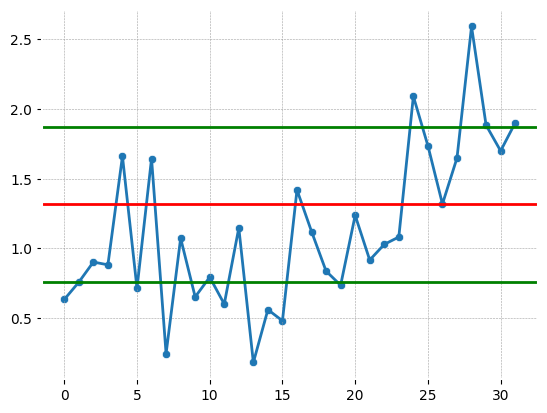

In [ ]:
inflect = Fun.get_inflections()

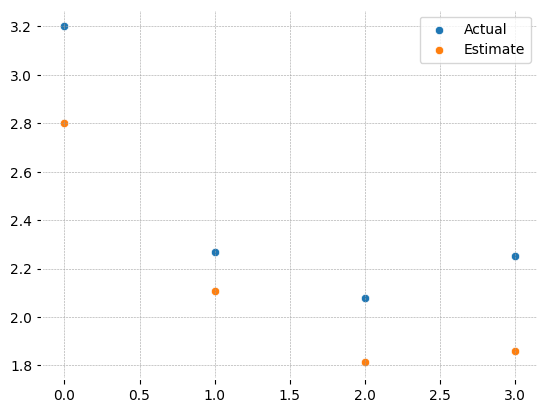

In [ ]:
surprise = Fun.eps_surprise()

2021-12-31   1719371000.00
2022-12-31   2329057000.00
2023-12-31   2875913000.00
2024-12-31   3304329000.00
Name: Total Revenue, dtype: float64
Revenue: [1.719371e+09 2.329057e+09 2.875913e+09 3.304329e+09]


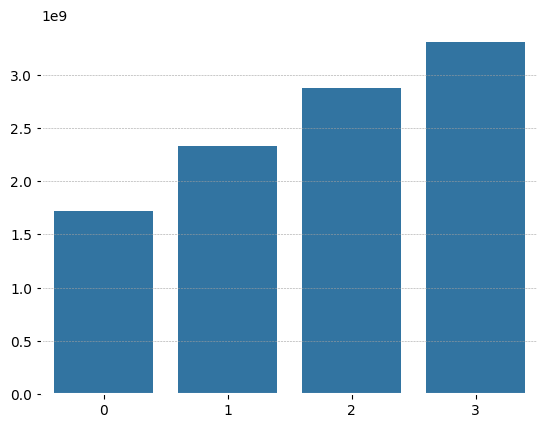

In [ ]:
revenue = Fun.revenue_growth()